In [1]:
from collections import OrderedDict
import torchvision
import torch
from zipfile import ZipFile
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import importlib
import numpy as np
import matplotlib.pyplot as plt
from lightning import seed_everything

## Transforms With Params
Of Note: the below transform returns (1) A clean and augmented view of an image and (2) the mean-centered/unit-variance standardized parameters of the transformations applied to obtain the augmented view. Come to think of it, you could just normalize right before the regression step, but c'est la vie.

Subsequent cells define the dataset class (similar to `imagenet_100_dataloading.ipynb` example, and a helper function for getting the train/test datasets).

In [2]:
from torchvision.transforms import RandomResizedCrop, ToTensor
import numpy as np
from typing import List
from tqdm import tqdm
import matplotlib.pyplot as plt

import torchaudio
import random
import scipy
import sys
import chcochleagram
from chcochleagram import compression
from chcochleagram import cochleagram
from chcochleagram import *
import logging
import sox 
import robustness.audio_functions.audio_transforms as at
importlib.reload(at)

class dBSNRAugmentation(object):
    def __init__(self, low_db=-10, high_db=10):
        super().__init__()
        self.torch_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=False)
        self.crop = at.CenterCrop(crop_length=40_000) # crop to middle 2 seconds
        self.combine_db_snr = at.CombineWithRandomDBSNRWithParam(low_db, high_db)


    def __call__(self, aud, background):
        logging.getLogger('sox').setLevel(logging.ERROR)

        assert aud is not None, " aud is None on input"
        clean_aud = self.crop(aud)
        assert clean_aud is not None, "clean aud is None post crop"
        # apply augmentations
        # sox aug first to match ssl training 
        assert clean_aud is not None, "clean aud is None post set level"
        clean_aud = torch.from_numpy(clean_aud)
        background = torch.from_numpy(background)
        aug_aud, db_snr = self.combine_db_snr(clean_aud, background)
        aug_aud, _ = self.torch_set_dbSPL(aug_aud, None)
        aug_aud = aug_aud.reshape(1,-1)
        db_SNR_param = torch.tensor([db_snr])
        clean_aud, _ = self.torch_set_dbSPL(clean_aud, None)
        clean_aud = clean_aud.reshape(1,-1)
        return (clean_aud, aug_aud), db_SNR_param
    

class FilterAugmentation(object):
    def __init__(self, low_db=-10, high_db=10):
        super().__init__()
        self.np_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=True)
        self.torch_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=False)
        self.crop = at.CenterCrop(crop_length=40_000) # crop to middle 2 seconds

        self.Pitch = at.ApplySingleAugmentSox('pitch', return_params=True)
        self.Tempo = at.ApplySingleAugmentSox('tempo', return_params=True)
        self.Filter = at.ApplySingleAugmentSox('filter', return_params=True)

    def __call__(self, aud, background):
        logging.getLogger('sox').setLevel(logging.ERROR)

        assert aud is not None, " aud is None on input"
        clean_aud = self.crop(aud)
        assert clean_aud is not None, "clean aud is None post crop"
        clean_aud, _ = self.np_set_dbSPL(clean_aud, None)
        # apply augmentations
        # sox aug first to match ssl training 
        assert clean_aud is not None, "clean aud is None post set level"
        aug_aud, n_semitones =  self.Pitch(clean_aud)
        aug_aud, temp_shift = self.Tempo(aug_aud)
        aug_aud, (order, low_cutoff, high_cutoff) = self.Filter(aug_aud)
        aug_aud = torch.from_numpy(aug_aud)
        aug_aud, _ = self.torch_set_dbSPL(aug_aud, None)
        aug_aud = aug_aud.reshape(1,-1)
        params = torch.tensor([n_semitones, temp_shift, order, low_cutoff, high_cutoff])
        clean_aud = torch.from_numpy(clean_aud).reshape(1,-1)
        return (clean_aud, aug_aud), params

db_snr_transform = dBSNRAugmentation()
filter_transform = FilterAugmentation()





#### Compute derived parameter stats

In [3]:
def get_mean_of_uniform(a,b):
    return (a+b) / 2 

def get_std_of_uniform(a,b):
    return np.sqrt(np.square(b-a) / 12.)

def get_std_of_discrete_uniform(a,b):
    return np.sqrt(np.square(b - a + 1 ) / 12.)

def get_uniform_stats(a,b):
    mean = get_mean_of_uniform(a,b)
    std = get_std_of_uniform(a,b)
    return mean, std

def get_discrete_uniform_stats(a,b):
    # mean is same as continuous
    mean = get_mean_of_uniform(a,b)
    # std is different 
    std = get_std_of_discrete_uniform(a,b)
    return mean, std

def get_mean_of_loguniform(a,b):
    return (b - a) / (np.log(b) - np.log(a))

def get_std_of_loguniform(a,b):
    # terms for variance 
    log_diff = np.log(b) - np.log(a)
    numerator = (log_diff) * (np.square(b) - np.square(a)) - (2 * np.square(b-a)) 
    denominator = 2 * np.square(log_diff)
    var = np.divide(numerator, denominator)
    std = np.sqrt(var)
    return std

def get_loguniform_stats(a,b):
    mean = get_mean_of_loguniform(a,b)
    std = get_std_of_loguniform(a,b)
    return mean, std

##############################
# Get stats per augmentation
##############################

snr_range = [-10, 10]
pitch_range = [-0.5, 0.5]
tempo_range = [-0.8, 1.2]

filter_order_range = [1, 4] # is discrete choice of 1,2,3,4; can treat as discrete uniform over 1-4
range_bandpass_freq_low = [4e1, 4e2]
range_bandpass_freq_high = [4e3, 10e3]


db_snr_mean, db_snr_std = get_uniform_stats(*snr_range)
pitch_mean, pitch_std = get_uniform_stats(*pitch_range)
tempo_mean, tempo_std = get_uniform_stats(*tempo_range)

order_mean, order_std = get_discrete_uniform_stats(*filter_order_range)
low_cutoff_mean, low_cutoff_std = get_loguniform_stats(*range_bandpass_freq_low)
high_cutoff_mean, high_cutoff_std = get_loguniform_stats(*range_bandpass_freq_high)

params_mean = np.array([db_snr_mean, pitch_mean, tempo_mean, order_mean, low_cutoff_mean, high_cutoff_mean],
                           dtype=np.float32)
params_std = np.array([db_snr_std, pitch_std, tempo_std, order_std, low_cutoff_std, high_cutoff_std],
                        dtype=np.float32)

In [4]:
from lightning_scripts.jsinV3DataLoader_precombined_batched import jsinV3_precombined_all_signals

batch_size = 96
jsin_path = '/mnt/ceph/users/jfeather/data/training_datasets_audio/JSIN_all_v3/subsets/'

train_dataset = jsinV3_precombined_all_signals(root=jsin_path,
                                        train=True,
                                        transform=None,
                                        batch_size=batch_size,
                                        train_max=5  # 10% of training set 
                                        )
val_dataset = jsinV3_precombined_all_signals(root=jsin_path,
                                        train=False,
                                        transform=None,
                                        batch_size=batch_size,
                                        eval_max=1)

In [5]:
# transforms = AudioAugmentStackWithParams()
db_snr_transform = dBSNRAugmentation()
filter_transform = FilterAugmentation()

# noise = np.random.randn(40000) * 0.02 # init white noise with variance at 0.02 RMS 
def snr_collate_fn(batch):
    batch = batch[0] # unbox wrapper added by dataloader 
    clean_signals = []
    augmented_signals = []
    params = []
    labels = batch[-1] # labels already collated 
    # convert labels to torch tensors 
    if isinstance(labels, dict):
        for task_key, task_labels in labels.items():
            labels[task_key] = torch.from_numpy(task_labels)
    else:
        labels = torch.from_numpy(labels) 
    # convert signal and noise into signal
    for (signal, noise) in  zip(*batch[:2]):
        if signal.sum() == 0 or signal is None:
            continue 
   
        else:
            (clean_sig, augment_sig), params_i = db_snr_transform(signal, noise)
            clean_signals.append(clean_sig)
            augmented_signals.append(augment_sig)
            params.append(params_i)
    clean_signals = torch.cat(clean_signals).unsqueeze(1).float() # add back channel dim
    augmented_signals = torch.cat(augmented_signals).unsqueeze(1).float() # add back channel dim
    params = torch.stack(params) # add back channel dim
    return clean_signals, augmented_signals, params, labels 


def filter_collate_fn(batch):
    batch = batch[0] # unbox wrapper added by dataloader 
    clean_signals = []
    augmented_signals = []
    params = []
    labels = batch[-1] # labels already collated 
    # convert labels to torch tensors 
    if isinstance(labels, dict):
        for task_key, task_labels in labels.items():
            labels[task_key] = torch.from_numpy(task_labels)
    else:
        labels = torch.from_numpy(labels) 
    # convert signal and noise into signal
    for (signal, _) in  zip(*batch[:2]):
        if signal.sum() == 0 or signal is None:
            continue 
   
        else:
            (clean_sig, augment_sig), params_i = filter_transform(signal, None)
            clean_signals.append(clean_sig)
            augmented_signals.append(augment_sig)
            params.append(params_i)
    clean_signals = torch.cat(clean_signals).unsqueeze(1).float() # add back channel dim
    augmented_signals = torch.cat(augmented_signals).unsqueeze(1).float() # add back channel dim
    params = torch.stack(params) # add back channel dim
    return clean_signals, augmented_signals, params, labels 

In [6]:
snr_train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=snr_collate_fn
        )

filter_train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=filter_collate_fn
        )

snr_test_loader = torch.utils.data.DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=snr_collate_fn
        )

filter_test_loader = torch.utils.data.DataLoader(
            val_dataset,
            batch_size=1,
            shuffle=False,
            num_workers=10,
            pin_memory=True,
            collate_fn=filter_collate_fn
        )


In [7]:
clean, aug, params, _ =  next(iter(filter_test_loader))


In [8]:
from IPython.display import display, Audio


eg_ix = 2
display(Audio(clean[eg_ix], rate=20_000, normalize=False))
display(Audio(aug[eg_ix], rate=20_000, normalize=False))
params[eg_ix]

tensor([1.5746e-01, 8.1622e-01, 1.0000e+00, 1.2272e+02, 8.1542e+03],
       dtype=torch.float64)

## Feature Extraction

- load a pair of models
- extract features in response to clean/augmented views for each

In [9]:
def get_rep_wrapped_model(model, input, layer):
    if layer == 'invar_head':
        feature, rep, logits = model(input)
        if len(rep) == 2:
            rep, _ = rep
    elif layer == 'equivar_head':
        feature, (_, rep), logits = model(input)
    else:
        predictions, rep, all_outputs = model(input,  with_latent=True, fake_relu=False)
        rep = all_outputs[layer]
    rep = rep.flatten(start_dim=1)
    return rep
  
def extract_features_param_decoding(model, loader, num_batches=None):
    if num_batches is None:
        num_batches = len(loader)

    responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2,  = [], [], [], []
    params, labels = [], []
    n_ = 0
    with torch.no_grad():
        for clean_audio, augmented_audio, param, label in tqdm(loader):
            clean_audio = clean_audio.cuda()
            augmented_audio = augmented_audio.cuda()
            # get invar head as model 1
            responses_clean_1.append(get_rep_wrapped_model(model, clean_audio, 'invar_head'))
            responses_augmented_1.append(get_rep_wrapped_model(model, augmented_audio, 'invar_head'))
            # get equivar head as model 2 
            responses_clean_2.append(get_rep_wrapped_model(model, clean_audio, 'equivar_head'))
            responses_augmented_2.append(get_rep_wrapped_model(model, augmented_audio, 'equivar_head'))

            params.append(param)
            labels.append(label)
            n_ += 1
            if n_ == num_batches:
                break

    responses_clean_1 = torch.cat(responses_clean_1)
    responses_augmented_1 = torch.cat(responses_augmented_1)
    responses_clean_2 = torch.cat(responses_clean_2)
    responses_augmented_2 = torch.cat(responses_augmented_2)

    params = torch.cat(params)
    # labels = torch.cat(labels)

    return responses_clean_1, responses_augmented_1, responses_clean_2, responses_augmented_2, params, None

In [10]:
import yaml 
import os
from pathlib import Path
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL
# import lightning_scripts.architectures as architectures
# from robustness.audio_functions.audio_input_representations import AUDIO_INPUT_REPRESENTATIONS


ckpt_dir = Path("model_checkpoints")

equi_model_base = 'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_5e-01'
# path_model_equivariant = f'model_checkpoints/{equi_model_base}/checkpoints/epoch=115-step=26100-best_val.ckpt'

equivar_ckpt_dir = ckpt_dir / f"{equi_model_base}/checkpoints"
path_model_equivariant = sorted(equivar_ckpt_dir.glob("*.ckpt"), key=os.path.getctime)[-1]
print('Equivariant checkpoint path: ', path_model_equivariant)


config_model_equivariant_path = f'model_configs/{equi_model_base}.yaml'
config_model_equivariant = yaml.load(open(config_model_equivariant_path, 'r'), Loader=yaml.FullLoader)

equivariant_model = LitAudioSSL.load_from_checkpoint(config=config_model_equivariant, checkpoint_path=path_model_equivariant).model.cuda().eval()# .model.cuda().eval()


Equivariant checkpoint path:  model_checkpoints/resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_5e-01/checkpoints/epoch=115-step=26100-best_val.ckpt


In [11]:
seed_everything(0)

# Extract Features for snr decoding 
rc_test_1, ra_test_1, rc_test_2, ra_test_2, params_test, labels_test = extract_features_param_decoding(
    equivariant_model, 
    snr_test_loader,
    num_batches=5,
)
rc_train_1, ra_train_1, rc_train_2, ra_train_2, params_train, labels_train = extract_features_param_decoding(
    equivariant_model, 
    snr_train_loader,
    num_batches=50,
)

X1_train = torch.cat([rc_train_1, ra_train_1], dim=1).detach().cpu().numpy()
X2_train = torch.cat([rc_train_2, ra_train_2], dim=1).detach().cpu().numpy()

X1_test = torch.cat([rc_test_1, ra_test_1], dim=1).detach().cpu().numpy()
X2_test = torch.cat([rc_test_2, ra_test_2], dim=1).detach().cpu().numpy()

X1_test = X1_test.reshape(X1_test.shape[0], -1)
X2_test = X2_test.reshape(X2_test.shape[0], -1)


## Cut params to just be db SNR
Y_train_db_SNR = params_train[:,0].detach().cpu().numpy()
Y_test_db_SNR = params_test[:,0].detach().cpu().numpy()

# get valid example ixs (where SNR is not inf)
train_IXS = np.argwhere(~np.isinf(Y_train_db_SNR)).flatten()
test_IXS = np.argwhere(~np.isinf(Y_test_db_SNR)).flatten()

X1_train = X1_train[train_IXS]
X1_test = X1_test[test_IXS]

X2_train = X2_train[train_IXS]
X2_test = X2_test[test_IXS]

Y_train_db_SNR = Y_train_db_SNR[train_IXS].reshape(-1,1)
Y_test_db_SNR = Y_test_db_SNR[test_IXS].reshape(-1,1)

## norm parameters 
# db_snr_mean = params_mean[0]
# db_snr_std = params_std[0]

# use emperical stats 
db_snr_mean = Y_train_db_SNR.mean(0)
db_snr_std = Y_train_db_SNR.std(0)

Y_train_db_SNR = (Y_train_db_SNR - db_snr_mean) / db_snr_std
Y_test_db_SNR  = (Y_test_db_SNR - db_snr_mean) / db_snr_std

alpha=0.5

regression_1_db_snr = Ridge(alpha=alpha).fit(X1_train, Y_train_db_SNR)
regression_2_db_snr = Ridge(alpha=alpha).fit(X2_train, Y_train_db_SNR)

score_1_db_snr = regression_1_db_snr.score(X1_test, Y_test_db_SNR)
score_2_db_snr = regression_2_db_snr.score(X2_test, Y_test_db_SNR)

preds_1_db_snr = regression_1_db_snr.predict(X1_test).reshape(-1,1)
preds_2_db_snr = regression_2_db_snr.predict(X2_test).reshape(-1,1)

[rank: 0] Seed set to 0
  0%|          | 0/175 [00:00<?, ?it/s]

  3%|▎         | 49/1510 [00:36<18:07,  1.34it/s]


In [12]:
seed_everything(0)

# Extract Features for snr decoding 
rc_test_1_filter, ra_test_1_filter, rc_test_2_filter, ra_test_2_filter, params_test_filter, labels_test_filter = extract_features_param_decoding(
    equivariant_model, 
    filter_test_loader,
    num_batches=5,
)
rc_train_1_filter, ra_train_1_filter, rc_train_2_filter, ra_train_2_filter, params_train_filter, labels_train_filter = extract_features_param_decoding(
    equivariant_model, 
    filter_train_loader,
    num_batches=50,
)


X1_train_filter = torch.cat([rc_train_1_filter, ra_train_1_filter], dim=1).detach().cpu().numpy()
X2_train_filter = torch.cat([rc_train_2_filter, ra_train_2_filter], dim=1).detach().cpu().numpy()

X1_test_filter = torch.cat([rc_test_1_filter, ra_test_1_filter], dim=1).detach().cpu().numpy()
X2_test_filter = torch.cat([rc_test_2_filter, ra_test_2_filter], dim=1).detach().cpu().numpy()

X1_test_filter = X1_test_filter.reshape(X1_test_filter.shape[0], -1)
X2_test_filter = X2_test_filter.reshape(X2_test_filter.shape[0], -1)

## Cut params to just be db SNR
Y_train_filter = params_train_filter.detach().cpu().numpy()
Y_test_filter = params_test_filter.detach().cpu().numpy()

## norm parameters 
# filter_mean = params_mean[1:]
# filter_std = params_std[1:]

# Try emperical means 
filter_mean = Y_train_filter.mean(0)
filter_std = Y_train_filter.std(0)

Y_train_filter = (Y_train_filter - filter_mean) / filter_std
Y_test_filter  = (Y_test_filter - filter_mean) / filter_std

regression_1_filter =  Ridge(alpha=alpha).fit(X1_train_filter, Y_train_filter)
regression_2_filter =  Ridge(alpha=alpha).fit(X2_train_filter, Y_train_filter)

score_1_filter = regression_1_filter.score(X1_test_filter, Y_test_filter)
score_2_filter = regression_2_filter.score(X2_test_filter, Y_test_filter)

preds_1_filter = regression_1_filter.predict(X1_test_filter)
preds_2_filter = regression_2_filter.predict(X2_test_filter)

[rank: 0] Seed set to 0
  0%|          | 0/175 [00:00<?, ?it/s]

  3%|▎         | 49/1510 [00:43<21:39,  1.12it/s] 


## Evaluation/Visualization

In [22]:
# can additionally score on each augmentation individually
# db_snr, n_semitones, temp_shift, order, low_cutoff, high_cutoff
AUGMENTATION_LIST = ["dB SNR", "Pitch (semitones)", "% Time warp", "Filter order", "Filter low cutoff", "Filter high cutoff"]

r2_invariant, r2_equivariant = {}, {}
for _ in range(len(AUGMENTATION_LIST)):
    if _ == 0:
        r2_invariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test_db_SNR[:, _], preds_1_db_snr[:, _])
        r2_equivariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test_db_SNR[:, _], preds_2_db_snr[:, _])
    else:
        r2_invariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test_filter[:, _-1], preds_1_filter[:, _-1])
        r2_equivariant[AUGMENTATION_LIST[_]] =  r2_score(Y_test_filter[:, _-1], preds_2_filter[:, _-1])


data = dict(r2_invariant_head=r2_invariant, r2_equivariant_head=r2_equivariant)

In [23]:
r2_invariant

{'dB SNR': -0.1341303586959839,
 'Pitch (semitones)': 0.31122009019339814,
 '% Time warp': -0.10428408294304314,
 'Filter order': -0.04289405055837925,
 'Filter low cutoff': 0.0960985544441556,
 'Filter high cutoff': -0.11282853072869137}

In [24]:
r2_equivariant

{'dB SNR': 0.5723901391029358,
 'Pitch (semitones)': 0.017973776604447433,
 '% Time warp': 0.6900243141158081,
 'Filter order': 0.33786098528522435,
 'Filter low cutoff': 0.4973230407645878,
 'Filter high cutoff': 0.4017453284443898}

Invariant dB Score: -0.134, Equivariant dB Score: 0.572
Invariant filter Score: 0.029, Equivariant filter Score: 0.389


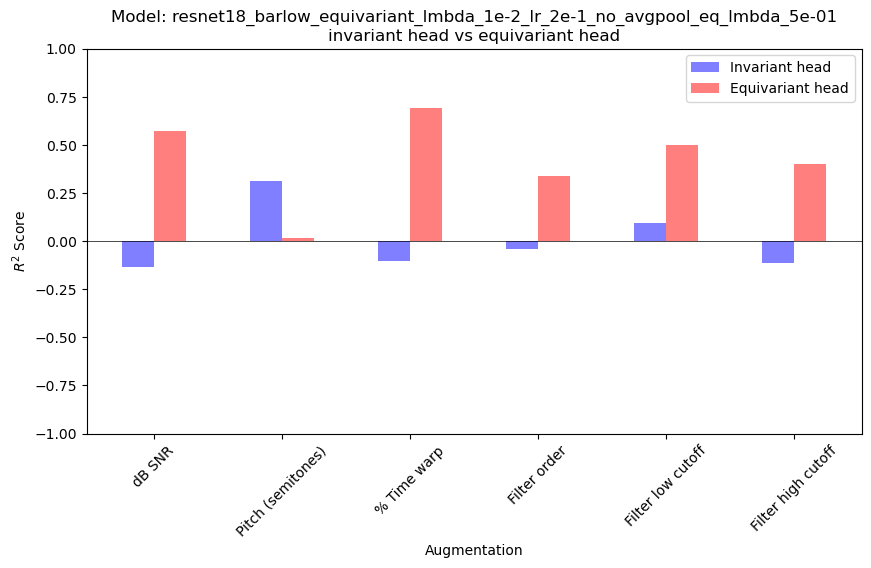

In [16]:
print(f"Invariant dB Score: {score_1_db_snr:.3f}, Equivariant dB Score: {score_2_db_snr:.3f}")
print(f"Invariant filter Score: {score_1_filter:.3f}, Equivariant filter Score: {score_2_filter:.3f}")

plt.figure(figsize=(10, 5))
bar_width = 0.25
bar_x = np.arange(len(r2_invariant.keys()))
plt.bar(bar_x, r2_invariant.values(), color='blue', alpha=0.5, label='Invariant head', width=bar_width)
plt.bar(bar_x + bar_width, r2_equivariant.values(), color='red', alpha=0.5, label='Equivariant head', width=bar_width)
plt.axhline(0, color='k', lw=0.5)
plt.xticks(rotation=45, ticks=bar_x + (bar_width * 0.5), labels=list(r2_invariant.keys()))
plt.xlabel('Augmentation')
plt.ylabel('$R^2$ Score')
plt.ylim(-1,1)

plt.title(f"Model: {equi_model_base}\ninvariant head vs equivariant head")

plt.legend()

fig_out_dir = Path('parameter_decoding') / equi_model_base
fig_out_dir.mkdir(parents=True, exist_ok=True)
fig_out_name = fig_out_dir / f"invar_head_vs_equivar_head_param_decoding_r2_by_augmentation"
# plt.savefig(fig_out_name, transparent=False, bbox_inches='tight' )


In [17]:
from scipy.stats import pearsonr

pearsonr_vec = np.vectorize(scipy.stats.pearsonr,
                signature='(n),(n)->(),()') 

def pr2_score(true, pred):
    r, _ = pearsonr_vec(true, pred)
    signs = np.sign(r)
    return signs * np.power(r, 2)

In [18]:
# can additionally score on each augmentation individually
# db_snr, n_semitones, temp_shift, order, low_cutoff, high_cutoff
AUGMENTATION_LIST = ["dB SNR", "Pitch (semitones)", "% Time warp", "Filter order", "Filter low cutoff", "Filter high cutoff"]

r2_invariant_pr2, r2_equivariant_pr2 = {}, {}
for _ in range(len(AUGMENTATION_LIST)):
    if _ == 0:
        r2_invariant_pr2[AUGMENTATION_LIST[_]] =  pr2_score(Y_test_db_SNR[:, _], preds_1_db_snr[:, _])
        r2_equivariant_pr2[AUGMENTATION_LIST[_]] =  pr2_score(Y_test_db_SNR[:, _], preds_2_db_snr[:, _])
    else:
        r2_invariant_pr2[AUGMENTATION_LIST[_]] =  pr2_score(Y_test_filter[:, _-1], preds_1_filter[:, _-1])
        r2_equivariant_pr2[AUGMENTATION_LIST[_]] =  pr2_score(Y_test_filter[:, _-1], preds_2_filter[:, _-1])


data['pr2_invariant_head'] = r2_invariant_pr2 
data['pr2_equivariant_head'] = r2_equivariant_pr2 

In [19]:
## Save out parameter decoding values 
import pickle 

data_out_name = Path('parameter_decoding') / f"{equi_model_base}" / f"invar_equivar_ssl_head_r2_decoding_values.pkl"

with open(data_out_name, 'wb') as handle:
    pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)


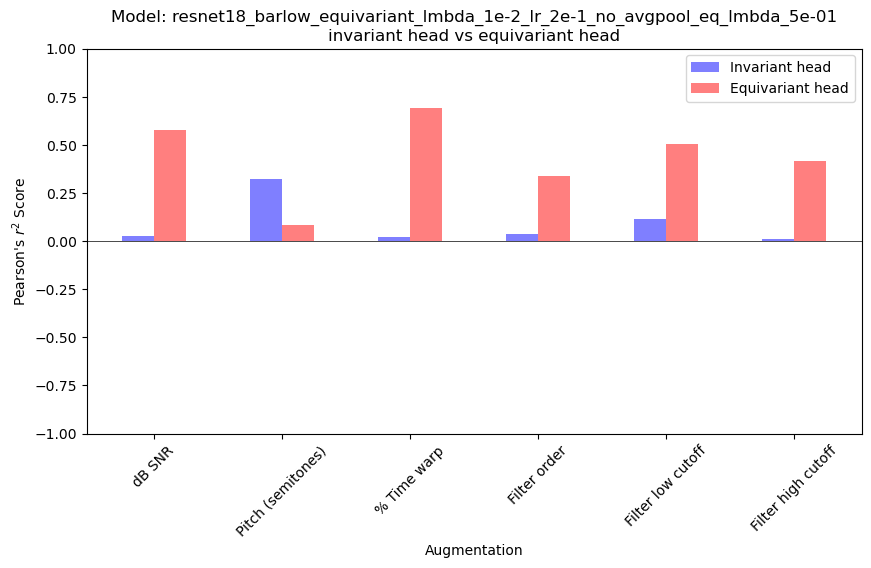

In [20]:
# print(f"Invariant Score: {score_1:.3f}, Equivariant Score: {score_2:.3f}")
plt.figure(figsize=(10, 5))
bar_width = 0.25
bar_x = np.arange(len(r2_invariant_pr2.keys()))
plt.bar(bar_x, r2_invariant_pr2.values(), color='blue', alpha=0.5, label='Invariant head', width=bar_width)
plt.bar(bar_x + bar_width, r2_equivariant_pr2.values(), color='red', alpha=0.5, label='Equivariant head', width=bar_width)
plt.axhline(0, color='k', lw=0.5)
plt.xticks(rotation=45, ticks=bar_x + (bar_width * 0.5), labels=list(r2_invariant.keys()))
plt.xlabel('Augmentation')
plt.ylabel("Pearson's $r^2$ Score")
plt.ylim(-1,1)

plt.title(f"Model: {equi_model_base}\ninvariant head vs equivariant head")

plt.legend()

# fig_out_dir = Path('parameter_decoding') / equi_model_base
# fig_out_dir.mkdir(parents=True, exist_ok=True)
# fig_out_name = fig_out_dir / f"invar_head_vs_equivar_head_param_decoding_r2_by_augmentation"
# plt.savefig(fig_out_name, transparent=False, bbox_inches='tight' )


<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:39: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1813547/3941066618.py:39: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f"ResNet18 Equivariant $\lambda$ {float(equi_model_base.split('_')[-1])}\nLayer4")


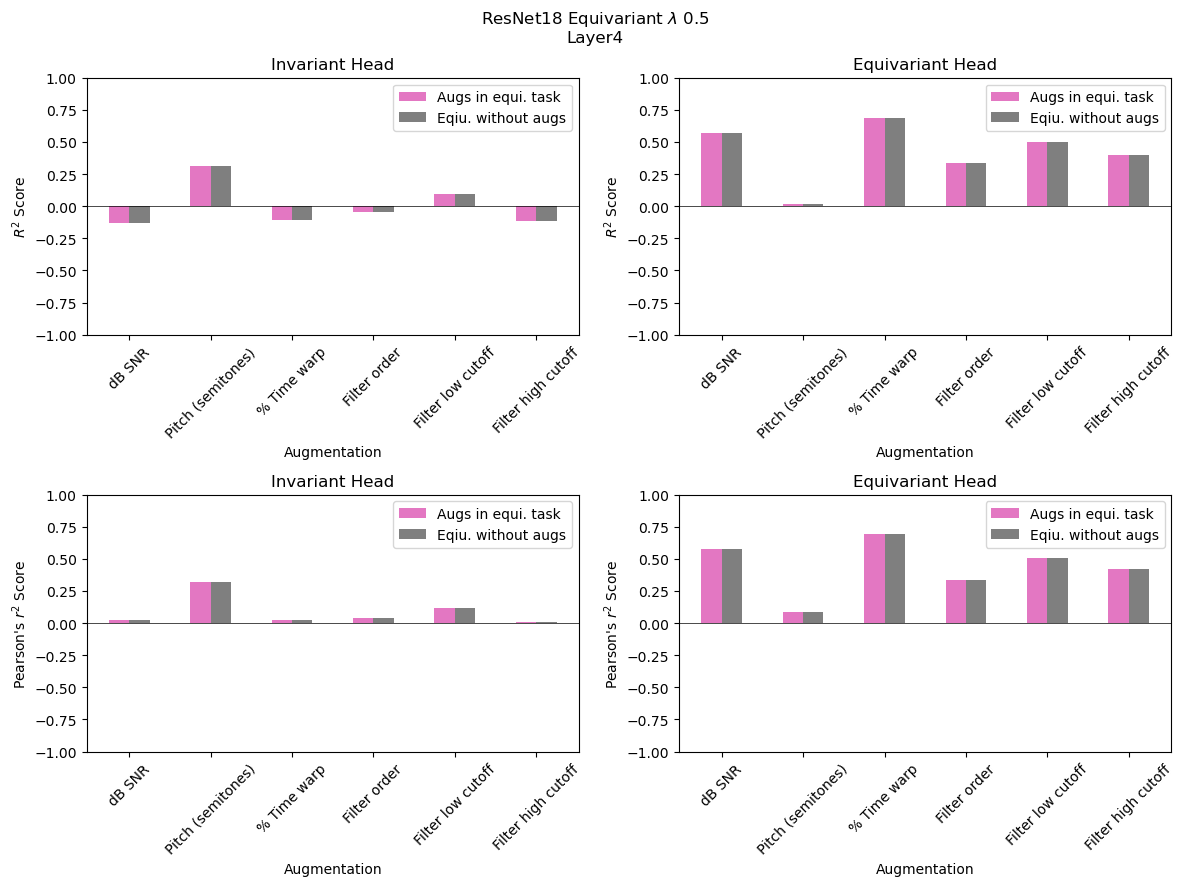

In [21]:
import copy
import pandas as pd 


no_aug_data = copy.deepcopy(data)

aug_base = 'resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_5e-01'
pd_fname  = Path('parameter_decoding') / f"{aug_base}" / f"invar_equivar_ssl_head_r2_decoding_values.pkl"

aug_data = pd.read_pickle(pd_fname)



fig, axs = plt.subplots(2, 2, figsize=(12,9))
# axs = axs[0,:]
# paxs = axs[1,:]

bar_width = 0.25
bar_x = np.arange(len(r2_invariant_pr2.keys()))
tasks = ['invariant_head', 'equivariant_head']

for ix, head in enumerate(tasks):
    for jx, score in enumerate(['r2', 'pr2']):
        axs[jx, ix].bar(bar_x, aug_data[f"{score}_{head}"].values(), color='tab:pink', label='Augs in equi. task', width=bar_width)
        axs[jx, ix].bar(bar_x + bar_width, no_aug_data[f"{score}_{head}"].values(), color='tab:grey', label='Eqiu. without augs', width=bar_width)
        axs[jx, ix].axhline(0, color='k', lw=0.5)
        axs[jx, ix].set_xticks(rotation=45, ticks=bar_x + (bar_width * 0.5), labels=list(r2_invariant.keys()))
        axs[jx, ix].set_xlabel('Augmentation')
        axs[jx, ix].legend()

        if jx == 0:
            axs[jx, ix].set_ylabel("$R^2$ Score")
        else:
            axs[jx, ix].set_ylabel("Pearson's $r^2$ Score")

        axs[jx, ix].set_ylim(-1,1)
        axs[jx, ix].set_title(f"{head.replace('_', ' ').title()}")

fig.suptitle(f"ResNet18 Equivariant $\lambda$ {float(equi_model_base.split('_')[-1])}\nLayer4")
plt.tight_layout()